# 03 — Arrival Classification Model (V9.0)

**LightGBM + XGBoost + CatBoost baseline → CatBoost Optuna 调优 → Threshold优化 → Risk Tier**

21 features (V8.0的18 + 3个V9.0新特征: lga_wx_impact, faa_event_duration_hours, faa_active_event_count)

In [1]:
# Standard imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# ML imports
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# === Project paths (RCF: only change BASE_DIR) ===
BASE_DIR = Path('../../..')             # RCF: Path('/path/to/project')
if not (BASE_DIR / 'src').exists():
    BASE_DIR = Path('../../..')
sys.path.insert(0, str(BASE_DIR / 'src'))

from features.lag_features import add_lag_features, add_congestion_features, compute_v4_lag_features
from features.aircraft_features import compute_prev_aircraft_delay
from models.threshold_optimizer import (
    find_optimal_threshold, evaluate_at_threshold,
    plot_threshold_analysis, get_business_metrics
)

# Paths
PROJECT_ROOT = BASE_DIR  # backward compat for plot save paths
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("Imports complete (LightGBM + XGBoost + Lag Features + V4.0 + Aircraft).")

Imports complete (LightGBM + XGBoost + Lag Features + V4.0 + Aircraft).


## 1. Load Data

In [2]:
# Load data and sort by time
df = pd.read_parquet(DATA_PROCESSED / 'arrivals_with_features.parquet')
df = df.sort_values('Scheduled_Arrival_Datetime').reset_index(drop=True)

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

print(f"Loaded {len(df):,} records")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Target distribution: {df['Is_Delayed'].value_counts().to_dict()}")
print(f"Delay rate: {df['Is_Delayed'].mean()*100:.1f}%")

# Load V4.0 auxiliary data for lag features
df_departures = None
dep_lag_path = DATA_PROCESSED / 'departures_for_lag.parquet'
if dep_lag_path.exists():
    df_departures = pd.read_parquet(dep_lag_path)
    print(f"\nLoaded departures for lag: {len(df_departures):,} records")
else:
    print("\nDepartures data not available — V4.0 lag features lga_dep_delay_1h, lga_capacity_util will be 0")

df_missed = None
ma_lag_path = DATA_PROCESSED / 'missed_approaches_for_lag.parquet'
if ma_lag_path.exists():
    df_missed = pd.read_parquet(ma_lag_path)
    print(f"Loaded missed approaches for lag: {len(df_missed):,} records")
else:
    print("Missed approaches data not available — missed_approach_1h will be 0")

Loaded 148,165 records
Date range: 2024-12-31 00:00:00 to 2025-10-31 00:00:00
Target distribution: {0: 113856, 1: 34309}
Delay rate: 23.2%

Loaded departures for lag: 148,061 records
Loaded missed approaches for lag: 1,051 records


## 2. Train/Test Split (70/30)

Split by date to simulate real-world deployment (train on past, predict future).
Approximately Aug 1 cutoff based on 70th percentile of dates.

In [3]:
# 70/30 time-based split
cutoff = df['Date'].quantile(0.7)
train = df[df['Date'] <= cutoff].copy()
test = df[df['Date'] > cutoff].copy()

print(f"Cutoff date: {cutoff}")
print(f"Train: {len(train):,} samples ({train['Is_Delayed'].mean()*100:.1f}% delayed)")
print(f"  Date range: {train['Date'].min()} to {train['Date'].max()}")
print(f"Test:  {len(test):,} samples ({test['Is_Delayed'].mean()*100:.1f}% delayed)")
print(f"  Date range: {test['Date'].min()} to {test['Date'].max()}")

Cutoff date: 2025-08-04 00:00:00
Train: 103,204 samples (24.4% delayed)
  Date range: 2024-12-31 00:00:00 to 2025-08-04 00:00:00
Test:  43,955 samples (20.8% delayed)
  Date range: 2025-08-05 00:00:00 to 2025-10-31 00:00:00


## 3. Lag Features (Post-Split)

Lag features are computed AFTER split to prevent data leakage.
- **Train**: computed directly on training data
- **Test**: uses last day of training data as context buffer, then removes context rows

In [4]:
# --- Train: compute lag features directly ---
train = add_lag_features(
    train,
    delay_col='Total_Calculated_Delay',
    datetime_col='Scheduled_Arrival_Datetime',
    date_col='Date',
    terminal_col='Terminal_Clean',
    airline_col='Marketing Airline Desc',
    origin_col='Non-PA Airport',
    verbose=True
)
train = add_congestion_features(
    train,
    datetime_col='Scheduled_Arrival_Datetime',
    date_col='Date',
    terminal_col='Terminal_Clean',
    verbose=True
)

# --- V4.0 lag features (train) ---
train = compute_v4_lag_features(
    train,
    df_departures=df_departures,
    df_missed=df_missed,
    datetime_col='Scheduled_Arrival_Datetime',
    date_col='Date',
    verbose=True
)

# --- Test: use train tail as context to avoid leakage ---
context_days = 1
context_date = test['Date'].min() - pd.Timedelta(days=context_days)
context = train[train['Date'] >= context_date].copy()
print(f"\nContext buffer: {len(context):,} rows from {context_date}")

test_with_context = pd.concat([context, test], ignore_index=True)
test_with_context = add_lag_features(
    test_with_context,
    delay_col='Total_Calculated_Delay',
    datetime_col='Scheduled_Arrival_Datetime',
    date_col='Date',
    terminal_col='Terminal_Clean',
    airline_col='Marketing Airline Desc',
    origin_col='Non-PA Airport',
    verbose=False
)
test_with_context = add_congestion_features(
    test_with_context,
    datetime_col='Scheduled_Arrival_Datetime',
    date_col='Date',
    terminal_col='Terminal_Clean',
    verbose=False
)

# V4.0 lag features (test with context)
test_with_context = compute_v4_lag_features(
    test_with_context,
    df_departures=df_departures,
    df_missed=df_missed,
    datetime_col='Scheduled_Arrival_Datetime',
    date_col='Date',
    verbose=False
)

# Remove context rows from test
test = test_with_context[test_with_context['Date'] > cutoff].copy()

print(f"\nAfter lag features:")
print(f"  Train: {len(train):,} rows")
print(f"  Test:  {len(test):,} rows")

# Verify lag features (including V4.0)
lag_cols = ['delay_rolling_1h', 'delay_rolling_3h', 'delay_rate_1h',
            'severe_delay_count_prev', 'terminal_delay_1h',
            'arrivals_prev_1h', 'arrivals_prev_3h', 'terminal_arrivals_prev_1h',
            'avg_taxi_in_1h', 'runway_config_change', 'lga_dep_delay_1h',
            'lga_capacity_util', 'missed_approach_1h']
print(f"\nLag feature null rates (train):")
for col in lag_cols:
    if col in train.columns:
        null_pct = train[col].isna().sum() / len(train) * 100
        print(f"  {col}: {null_pct:.1f}%")
    else:
        print(f"  {col}: NOT AVAILABLE")

Lag Features Added:
  - delay_rolling_1h: mean=12.13, null_count=0
  - delay_rolling_3h: mean=10.31, null_count=0
  - delay_rate_1h: mean=0.24, null_count=0
  - severe_delay_count_prev: mean=7.87, null_count=0
  - terminal_delay_1h: mean=12.02, null_count=0
Congestion Features Added:
  - arrivals_prev_1h: mean=29.5
  - arrivals_prev_3h: mean=83.4
  - terminal_arrivals_prev_1h: mean=13.9
V4.0 Lag Features Added:
  - avg_taxi_in_1h: mean=7.48, null=0.0%
  - runway_config_change: mean=0.28, null=0.0%
  - lga_dep_delay_1h: mean=15.67, null=0.0%
  - lga_capacity_util: mean=0.83, null=0.0%
  - missed_approach_1h: mean=0.15, null=0.0%

Context buffer: 542 rows from 2025-08-04 00:00:00

After lag features:
  Train: 103,204 rows
  Test:  43,955 rows

Lag feature null rates (train):
  delay_rolling_1h: 0.0%
  delay_rolling_3h: 0.0%
  delay_rate_1h: 0.0%
  severe_delay_count_prev: 0.0%
  terminal_delay_1h: 0.0%
  arrivals_prev_1h: 0.0%
  arrivals_prev_3h: 0.0%
  terminal_arrivals_prev_1h: 0.0%
  

## 4. Aircraft Continuity Features

Track the same aircraft (by Registration / tail number) across consecutive LGA arrivals.
When turnaround is short (<8h), the previous arrival's delay is a strong predictor (3-5x lift).

Same leakage prevention as lag features:
- Computed AFTER split, using `shift(1)` to exclude current observation
- Test uses train tail as context buffer

In [5]:
# --- Train: Aircraft continuity features ---
train = compute_prev_aircraft_delay(
    train, registration_col='Registration',
    datetime_col='Scheduled_Arrival_Datetime',
    delay_col='Total_Calculated_Delay',
    max_gap_hours=8, verbose=True
)

# --- Test: use train tail as context (same context already built above for lag features) ---
test_with_context2 = pd.concat([context, test], ignore_index=True)
test_with_context2 = compute_prev_aircraft_delay(
    test_with_context2, registration_col='Registration',
    datetime_col='Scheduled_Arrival_Datetime',
    delay_col='Total_Calculated_Delay',
    max_gap_hours=8, verbose=False
)
test = test_with_context2[test_with_context2['Date'] > cutoff].copy()

# Verify coverage (V7.0: 2 aircraft continuity features retained)
print(f"\nAircraft continuity feature coverage (train):")
for col in ['prev_aircraft_delay', 'turnaround_hours']:
    non_default = (train[col] != train[col].median()).sum()
    print(f"  {col}: {non_default:,} non-default values ({non_default/len(train)*100:.1f}%)")

Aircraft Continuity Features (V5.0):
  Flights with short-turnaround match: 24,628 / 103,204 (23.9%)
  - prev_aircraft_delay: mean=-7.88, non-null=103,204
  - prev_aircraft_delayed: mean=0.03, non-null=103,204
  - turnaround_hours: mean=5.55, non-null=103,204
  - turnaround_buffer: mean=4.80, non-null=103,204

Aircraft continuity feature coverage (train):
  prev_aircraft_delay: 23,886 non-default values (23.1%)
  turnaround_hours: 24,470 non-default values (23.7%)


## 5. Feature Columns & Preparation

Compute pressure change rate, define feature columns, and handle missing values.

In [6]:
# --- Compute origin pressure change rate (3-flight lag within same origin) ---
for subset in [train, test]:
    if 'origin_pressure' in subset.columns:
        subset.sort_values(['Non-PA Airport', 'Scheduled_Arrival_Datetime'], inplace=True)
        subset['origin_pressure_change_3h'] = (
            subset.groupby('Non-PA Airport')['origin_pressure']
            .transform(lambda x: x - x.shift(3))
        )
        print(f"origin_pressure_change_3h: {subset['origin_pressure_change_3h'].notna().sum():,} non-null")

# --- Gate/Terminal target encoding (replaces LabelEncoder per SHAP analysis) ---
gate_target = train.groupby('Gate')['Is_Delayed'].mean()
train['gate_delay_rate'] = train['Gate'].map(gate_target).fillna(train['Is_Delayed'].mean())
test['gate_delay_rate'] = test['Gate'].map(gate_target).fillna(train['Is_Delayed'].mean())

terminal_target = train.groupby('Terminal Code')['Is_Delayed'].mean()
train['terminal_delay_rate'] = train['Terminal Code'].map(terminal_target).fillna(train['Is_Delayed'].mean())
test['terminal_delay_rate'] = test['Terminal Code'].map(terminal_target).fillna(train['Is_Delayed'].mean())

print(f"\nTarget encoding (gate): {train['gate_delay_rate'].nunique()} unique values, "
      f"range [{train['gate_delay_rate'].min():.3f}, {train['gate_delay_rate'].max():.3f}]")
print(f"Target encoding (terminal): {train['terminal_delay_rate'].nunique()} unique values, "
      f"range [{train['terminal_delay_rate'].min():.3f}, {train['terminal_delay_rate'].max():.3f}]")

# --- V4.0 Target Encoding: airline, runway, FAA reason ---
airline_target = train.groupby('Marketing Airline Desc')['Is_Delayed'].mean()
train['airline_delay_rate'] = train['Marketing Airline Desc'].map(airline_target).fillna(train['Is_Delayed'].mean())
test['airline_delay_rate'] = test['Marketing Airline Desc'].map(airline_target).fillna(train['Is_Delayed'].mean())
print(f"Target encoding (airline): {train['airline_delay_rate'].nunique()} unique values, "
      f"range [{train['airline_delay_rate'].min():.3f}, {train['airline_delay_rate'].max():.3f}]")

runway_target = train.groupby('Runway_Clean')['Is_Delayed'].mean()
train['runway_delay_rate'] = train['Runway_Clean'].map(runway_target).fillna(train['Is_Delayed'].mean())
test['runway_delay_rate'] = test['Runway_Clean'].map(runway_target).fillna(train['Is_Delayed'].mean())
print(f"Target encoding (runway): {train['runway_delay_rate'].nunique()} unique values, "
      f"range [{train['runway_delay_rate'].min():.3f}, {train['runway_delay_rate'].max():.3f}]")

if 'faa_delay_reason_raw' in train.columns:
    faa_reason_target = train.groupby('faa_delay_reason_raw')['Is_Delayed'].mean()
    train['faa_delay_reason'] = train['faa_delay_reason_raw'].map(faa_reason_target).fillna(train['Is_Delayed'].mean())
    test['faa_delay_reason'] = test['faa_delay_reason_raw'].map(faa_reason_target).fillna(train['Is_Delayed'].mean())
    print(f"Target encoding (FAA reason): {train['faa_delay_reason'].nunique()} unique values, "
          f"range [{train['faa_delay_reason'].min():.3f}, {train['faa_delay_reason'].max():.3f}]")
    print(f"  Reason categories: {faa_reason_target.to_dict()}")
else:
    faa_reason_target = None
    print("faa_delay_reason_raw not available — skipping FAA reason target encoding")

origin_pressure_change_3h: 32,967 non-null
origin_pressure_change_3h: 12,131 non-null

Target encoding (gate): 88 unique values, range [0.000, 1.000]
Target encoding (terminal): 4 unique values, range [0.006, 0.265]
Target encoding (airline): 11 unique values, range [0.000, 0.329]
Target encoding (runway): 19 unique values, range [0.188, 0.738]
Target encoding (FAA reason): 5 unique values, range [0.194, 0.692]
  Reason categories: {'None': 0.19432312055819773, 'OTHER': 0.6540803897685749, 'STAFF': 0.4380165289256198, 'VOL': 0.23846153846153847, 'WX': 0.6922913343965975}


In [7]:
# --- Feature columns (V9.0: 21 features) ---
# V9.0 = V8.0 (18) + 6 new: wx impact scores, FAA event depth, LGA ceiling/pressure
# --- Feature columns (V9.0: 21 features = V8.0 18 + 3 new) ---
# Ablation test results: faa_event_duration_hours (+0.0058), faa_active_event_count (+0.0058),
# lga_wx_impact (+0.0017) confirmed beneficial. lga_ceiling_low, lga_pressure_falling dropped.
feature_columns = [
    # === Core Lag (5) ===
    'delay_rate_1h', 'terminal_delay_1h', 'severe_delay_count_prev',
    'delay_rolling_3h', 'lga_dep_delay_1h',
    # === Aircraft Continuity (2) ===
    'prev_aircraft_delay', 'turnaround_hours',
    # === Target Encoding (4) ===
    'gate_delay_rate', 'faa_delay_reason', 'runway_delay_rate', 'airline_delay_rate',
    # === Time (1) ===
    'Hour',
    # === Operational (2) ===
    'faa_delay_severity', 'runway_config_change',
    # === Origin Weather (3) ===
    'origin_dewpoint', 'origin_historical_delay', 'origin_wx_impact',
    # === Network (1) ===
    'route_risk_score',
    # === V9.0 New (3) ===
    'lga_wx_impact',                # +0.0017 AUC (re-added, Weather Impact Score)
    'faa_event_duration_hours',     # +0.0058 AUC (GDP/GSP event duration)
    'faa_active_event_count',       # +0.0058 AUC (simultaneous FAA events)
]

# Filter to only existing columns
available = [c for c in feature_columns if c in train.columns]
missing = [c for c in feature_columns if c not in train.columns]
if missing:
    print(f"\nWARNING: Missing features (skipped): {missing}")
feature_columns = available

print(f"\nFeatures: {len(feature_columns)} (V9.0)")
for i, f in enumerate(feature_columns, 1):
    print(f"  {i:2}. {f}")


Features: 21 (V9.0)
   1. delay_rate_1h
   2. terminal_delay_1h
   3. severe_delay_count_prev
   4. delay_rolling_3h
   5. lga_dep_delay_1h
   6. prev_aircraft_delay
   7. turnaround_hours
   8. gate_delay_rate
   9. faa_delay_reason
  10. runway_delay_rate
  11. airline_delay_rate
  12. Hour
  13. faa_delay_severity
  14. runway_config_change
  15. origin_dewpoint
  16. origin_historical_delay
  17. origin_wx_impact
  18. route_risk_score
  19. lga_wx_impact
  20. faa_event_duration_hours
  21. faa_active_event_count


In [8]:
# Prepare X/y
X_train = train[feature_columns].copy()
y_train = train['Is_Delayed'].copy()
X_test = test[feature_columns].copy()
y_test = test['Is_Delayed'].copy()

# Handle missing values (fill with training median)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.mean()*100:.1f}% delayed ({y_train.sum():,} / {len(y_train):,})")
print(f"y_test:  {y_test.mean()*100:.1f}% delayed ({y_test.sum():,} / {len(y_test):,})")

# Verify no NaN remaining
print(f"\nNaN remaining - Train: {X_train.isna().sum().sum()}, Test: {X_test.isna().sum().sum()}")

X_train: (103204, 21)
X_test:  (43955, 21)
y_train: 24.4% delayed (25,151 / 103,204)
y_test:  20.8% delayed (9,158 / 43,955)

NaN remaining - Train: 0, Test: 0


## 6. Temporal Decay Weights (Validation)

Address the train/test distribution shift (Train 28.9% delayed → Test 18.9% delayed)
by applying exponential decay weights — recent training data gets higher weight.

Grid search over `half_life × class_weight_ratio × threshold` to find the best combo.
`half_life=None` serves as baseline (no temporal decay, equivalent to original spw approach).

**V4.0-V6.0 RCF Result**: Temporal decay was NOT effective (Optuna chose use_temporal=False). 
Kept here for completeness.

In [9]:
from models.temporal_weights import compute_temporal_weights, combine_temporal_and_class_weights

# --- Temporal Decay Grid Search ---
# half_life: days for weight to halve. None = no decay (baseline).
# class_weight_ratio: replaces scale_pos_weight (applied via sample_weight)
half_lives = [7, 14, 21, 30, 45, 60, None]
cw_ratios = [3.0, 4.0, 5.0]
thresholds = [0.35, 0.40, 0.45, 0.50]

temporal_results = []

for hl in half_lives:
    for cwr in cw_ratios:
        # Compute sample weights
        if hl is not None:
            t_weights = compute_temporal_weights(train['Date'], cutoff, half_life=hl)
            sw = combine_temporal_and_class_weights(t_weights, y_train.values, cwr)
        else:
            # Baseline: class weights only (equivalent to scale_pos_weight)
            sw = np.where(y_train.values == 1, cwr, 1.0)

        # Train LGB with sample_weight (no scale_pos_weight)
        model = lgb.LGBMClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            random_state=42, verbose=-1
        )
        model.fit(X_train, y_train, sample_weight=sw)
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)

        for thresh in thresholds:
            metrics = evaluate_at_threshold(y_test.values, proba, thresh)
            temporal_results.append({
                'half_life': hl, 'class_weight': cwr, 'threshold': thresh,
                'auc': auc, 'precision': metrics['precision'],
                'recall': metrics['recall'], 'f1': metrics['f1'],
            })

    hl_str = f'{hl}d' if hl is not None else 'None'
    print(f'  half_life={hl_str}: AUC={auc:.4f}')

temporal_df = pd.DataFrame(temporal_results)
print(f'\nTemporal decay grid search: {len(temporal_df)} combinations')

# --- Select best combo (Recall >= 65%, max F1) ---
td_candidates = temporal_df[temporal_df['recall'] >= 0.65].copy()
if len(td_candidates) == 0:
    td_candidates = temporal_df.copy()
    print('WARNING: No combo achieves Recall >= 65%')

best_td = td_candidates.sort_values('f1', ascending=False).iloc[0]
print(f'\nBest temporal decay config:')
print(f'  half_life={best_td["half_life"]}, class_weight={best_td["class_weight"]:.1f}, threshold={best_td["threshold"]:.2f}')
print(f'  AUC={best_td["auc"]:.4f}, Precision={best_td["precision"]:.4f}, Recall={best_td["recall"]:.4f}, F1={best_td["f1"]:.4f}')

# Compare with baseline (half_life=None)
baseline = td_candidates[td_candidates['half_life'].isna()].sort_values('f1', ascending=False)
if len(baseline) > 0:
    best_baseline = baseline.iloc[0]
    print(f'\nBaseline (no decay): cwr={best_baseline["class_weight"]:.1f}, thresh={best_baseline["threshold"]:.2f}')
    print(f'  AUC={best_baseline["auc"]:.4f}, Precision={best_baseline["precision"]:.4f}, Recall={best_baseline["recall"]:.4f}, F1={best_baseline["f1"]:.4f}')
    print(f'\nTemporal decay improvement:')
    print(f'  AUC:       {best_td["auc"] - best_baseline["auc"]:+.4f}')
    print(f'  Precision: {best_td["precision"] - best_baseline["precision"]:+.4f}')
    print(f'  F1:        {best_td["f1"] - best_baseline["f1"]:+.4f}')

# Show top 10
print('\n' + '=' * 80)
print('TOP 10 TEMPORAL DECAY CONFIGS (Recall >= 65%, sorted by F1)')
print('=' * 80)
print(td_candidates.sort_values('f1', ascending=False).head(10).to_string(index=False))

  half_life=7d: AUC=0.7974
  half_life=14d: AUC=0.7999
  half_life=21d: AUC=0.8016
  half_life=30d: AUC=0.8038
  half_life=45d: AUC=0.8056
  half_life=60d: AUC=0.8063
  half_life=None: AUC=0.8065

Temporal decay grid search: 84 combinations

Best temporal decay config:
  half_life=nan, class_weight=3.0, threshold=0.45
  AUC=0.8058, Precision=0.4655, Recall=0.6631, F1=0.5470

Baseline (no decay): cwr=3.0, thresh=0.45
  AUC=0.8058, Precision=0.4655, Recall=0.6631, F1=0.5470

Temporal decay improvement:
  AUC:       +0.0000
  Precision: +0.0000
  F1:        +0.0000

TOP 10 TEMPORAL DECAY CONFIGS (Recall >= 65%, sorted by F1)
 half_life  class_weight  threshold      auc  precision   recall       f1
       NaN           3.0       0.45 0.805773   0.465507 0.663136 0.547019
      45.0           4.0       0.50 0.805840   0.461207 0.665975 0.544992
      30.0           4.0       0.50 0.804183   0.463634 0.659860 0.544611
      21.0           4.0       0.50 0.802071   0.459107 0.664446 0.543013


## 7. LightGBM + XGBoost Training

In [10]:
# Calculate base class weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
base_spw = neg_count / pos_count

print(f"Class distribution: {neg_count:,} negative, {pos_count:,} positive")
print(f"Base scale_pos_weight: {base_spw:.2f}")

# --- Grid search over scale_pos_weight ---
spw_values = [2.0, 2.5, 3.0, 3.5, 4.0]
grid_results = []

for spw in spw_values:
    # Train LightGBM
    model_lgb = lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=spw, random_state=42, verbose=-1
    )
    model_lgb.fit(X_train, y_train)
    proba_lgb = model_lgb.predict_proba(X_test)[:, 1]
    auc_lgb = roc_auc_score(y_test, proba_lgb)

    # Train XGBoost
    model_xgb = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=spw, random_state=42,
        use_label_encoder=False, eval_metric='logloss', verbosity=0
    )
    model_xgb.fit(X_train, y_train)
    proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
    auc_xgb = roc_auc_score(y_test, proba_xgb)

    # Evaluate at multiple thresholds
    for thresh in [0.40, 0.44, 0.48, 0.50]:
        for name, proba, auc_val in [('LGB', proba_lgb, auc_lgb), ('XGB', proba_xgb, auc_xgb)]:
            metrics = evaluate_at_threshold(y_test.values, proba, thresh)
            grid_results.append({
                'model': name, 'spw': spw, 'threshold': thresh,
                'auc': auc_val, 'precision': metrics['precision'],
                'recall': metrics['recall'], 'f1': metrics['f1'],
            })

    print(f"  spw={spw:.1f}: LGB AUC={auc_lgb:.4f}, XGB AUC={auc_xgb:.4f}")

grid_df = pd.DataFrame(grid_results)
print(f"\nGrid search complete: {len(grid_df)} combinations")

Class distribution: 78,053 negative, 25,151 positive
Base scale_pos_weight: 3.10
  spw=2.0: LGB AUC=0.8065, XGB AUC=0.8054
  spw=2.5: LGB AUC=0.8062, XGB AUC=0.8057
  spw=3.0: LGB AUC=0.8059, XGB AUC=0.8064
  spw=3.5: LGB AUC=0.8059, XGB AUC=0.8058
  spw=4.0: LGB AUC=0.8056, XGB AUC=0.8057

Grid search complete: 40 combinations


In [11]:
# --- Select best spw/threshold combo ---
# Target: Recall >= 65% AND highest Precision
candidates = grid_df[grid_df['recall'] >= 0.65].copy()
if len(candidates) == 0:
    # Fallback: highest recall
    candidates = grid_df.copy()
    print("WARNING: No combo achieves Recall >= 65%, selecting best available")

# For each model, pick highest F1 among candidates
best_configs = {}
for model_name in ['LGB', 'XGB']:
    model_candidates = candidates[candidates['model'] == model_name]
    best_row = model_candidates.sort_values('f1', ascending=False).iloc[0]
    best_configs[model_name] = best_row
    print(f"\nBest {model_name}: spw={best_row['spw']:.1f}, threshold={best_row['threshold']:.2f}")
    print(f"  AUC={best_row['auc']:.4f}, Precision={best_row['precision']:.4f}, "
          f"Recall={best_row['recall']:.4f}, F1={best_row['f1']:.4f}")

# Show full grid for reference
print("\n" + "="*80)
print("FULL GRID RESULTS (sorted by F1, Recall >= 65%)")
print("="*80)
display_df = candidates.sort_values('f1', ascending=False).head(15)
print(display_df.to_string(index=False))

# --- Train final models with best spw ---
best_lgb_spw = best_configs['LGB']['spw']
best_xgb_spw = best_configs['XGB']['spw']

lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=best_lgb_spw, random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)
print(f"\nFinal LightGBM trained (spw={best_lgb_spw:.1f})")

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=best_xgb_spw, random_state=42,
    use_label_encoder=False, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train)
print(f"Final XGBoost trained (spw={best_xgb_spw:.1f})")


Best LGB: spw=3.5, threshold=0.48
  AUC=0.8059, Precision=0.4643, Recall=0.6652, F1=0.5469

Best XGB: spw=3.5, threshold=0.50
  AUC=0.8058, Precision=0.4706, Recall=0.6614, F1=0.5499

FULL GRID RESULTS (sorted by F1, Recall >= 65%)
model  spw  threshold      auc  precision   recall       f1
  XGB  3.5       0.50 0.805761   0.470593 0.661389 0.549911
  LGB  3.5       0.48 0.805856   0.464294 0.665211 0.546883
  XGB  3.0       0.44 0.806352   0.457055 0.679843 0.546620
  LGB  2.5       0.40 0.806204   0.459512 0.670452 0.545293
  XGB  2.5       0.40 0.805663   0.456814 0.675693 0.545102
  XGB  3.5       0.48 0.805761   0.450440 0.681808 0.542485
  LGB  3.0       0.44 0.805882   0.453663 0.673509 0.542146
  LGB  4.0       0.50 0.805603   0.447818 0.684538 0.541435
  XGB  4.0       0.50 0.805697   0.444563 0.684320 0.538981
  LGB  4.0       0.48 0.805603   0.428496 0.706377 0.533416
  XGB  4.0       0.48 0.805697   0.427103 0.707578 0.532676
  LGB  3.5       0.44 0.805856   0.425786 0.708

In [12]:
# (XGBoost training moved to cell above as part of grid search)

In [13]:

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

lgb_auc = roc_auc_score(y_test, lgb_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"LightGBM  AUC: {lgb_auc:.4f}  (spw={best_lgb_spw:.1f})")

print(f"XGBoost   AUC: {xgb_auc:.4f}  (spw={best_xgb_spw:.1f})")


LightGBM  AUC: 0.8059  (spw=3.5)
XGBoost   AUC: 0.8058  (spw=3.5)


## 8. CatBoost Training

In [14]:
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from pathlib import Path
FIGURES_DIR = Path('../../..') / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('CatBoost section imports ready')

CatBoost section imports ready


### 8.1 CatBoost Temporal Decay

CatBoost uses `auto_class_weights='Balanced'` which handles class imbalance internally.
For temporal decay, we only pass temporal-only weights to `sample_weight` — CatBoost's
balanced mode will re-weight classes on top of the temporal weights.

In [15]:
from models.temporal_weights import compute_temporal_weights

# --- CatBoost Temporal Decay Grid Search ---
# For CatBoost: keep auto_class_weights='Balanced', pass temporal-only weights
half_lives_cat = [14, 21, 30, 45, None]
cat_td_results = []

for hl in half_lives_cat:
    if hl is not None:
        t_weights = compute_temporal_weights(train['Date'], cutoff, half_life=hl)
    else:
        t_weights = None  # baseline: no temporal decay

    cat_td = CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.05,
        auto_class_weights='Balanced', random_seed=42, verbose=0
    )

    if t_weights is not None:
        cat_td.fit(X_train, y_train, sample_weight=t_weights)
    else:
        cat_td.fit(X_train, y_train)

    proba = cat_td.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)

    for thresh in [0.35, 0.40, 0.45, 0.50]:
        metrics = evaluate_at_threshold(y_test.values, proba, thresh)
        cat_td_results.append({
            'half_life': hl, 'threshold': thresh,
            'auc': auc, 'precision': metrics['precision'],
            'recall': metrics['recall'], 'f1': metrics['f1'],
        })

    hl_str = f'{hl}d' if hl is not None else 'None'
    print(f'  CatBoost half_life={hl_str}: AUC={auc:.4f}')

cat_td_df = pd.DataFrame(cat_td_results)

# Best config (Recall >= 65%)
cat_td_cands = cat_td_df[cat_td_df['recall'] >= 0.65].copy()
if len(cat_td_cands) == 0:
    cat_td_cands = cat_td_df.copy()
    print('WARNING: No CatBoost combo achieves Recall >= 65%')

best_cat_td = cat_td_cands.sort_values('f1', ascending=False).iloc[0]
print(f'\nBest CatBoost temporal decay:')
print(f'  half_life={best_cat_td["half_life"]}, threshold={best_cat_td["threshold"]:.2f}')
print(f'  AUC={best_cat_td["auc"]:.4f}, P={best_cat_td["precision"]:.4f}, R={best_cat_td["recall"]:.4f}, F1={best_cat_td["f1"]:.4f}')

# Baseline comparison
baseline_cat = cat_td_cands[cat_td_cands['half_life'].isna()].sort_values('f1', ascending=False)
if len(baseline_cat) > 0:
    bl = baseline_cat.iloc[0]
    print(f'\nBaseline (no decay): thresh={bl["threshold"]:.2f}')
    print(f'  AUC={bl["auc"]:.4f}, P={bl["precision"]:.4f}, R={bl["recall"]:.4f}, F1={bl["f1"]:.4f}')
    print(f'  Improvement: AUC {best_cat_td["auc"] - bl["auc"]:+.4f}, P {best_cat_td["precision"] - bl["precision"]:+.4f}, F1 {best_cat_td["f1"] - bl["f1"]:+.4f}')

  CatBoost half_life=14d: AUC=0.8042
  CatBoost half_life=21d: AUC=0.8052
  CatBoost half_life=30d: AUC=0.8062
  CatBoost half_life=45d: AUC=0.8063
  CatBoost half_life=None: AUC=0.8038

Best CatBoost temporal decay:
  half_life=30.0, threshold=0.40
  AUC=0.8062, P=0.4642, R=0.6624, F1=0.5458

Baseline (no decay): thresh=0.45
  AUC=0.8038, P=0.4631, R=0.6585, F1=0.5438
  Improvement: AUC +0.0024, P +0.0011, F1 +0.0021



### 8.2 CatBoost Baseline Training

In [16]:
# --- Train three models for comparison ---

# LightGBM v3 baseline
lgb_v3 = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=4.0, random_state=42, verbose=-1
)
lgb_v3.fit(X_train, y_train)
lgb_proba = lgb_v3.predict_proba(X_test)[:, 1]

# XGBoost baseline (same config as 03)
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=4.0, random_state=42, verbosity=0,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# CatBoost: auto_class_weights='Balanced'
cat_balanced = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
cat_balanced.fit(X_train, y_train)
cat_bal_proba = cat_balanced.predict_proba(X_test)[:, 1]

# CatBoost: scale_pos_weight=4.0
cat_spw = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.05,
    scale_pos_weight=4.0, random_seed=42, verbose=0
)
cat_spw.fit(X_train, y_train)
cat_spw_proba = cat_spw.predict_proba(X_test)[:, 1]

print('All models trained.')

All models trained.


## 9. Three-Model Comparison (LGB vs XGB vs CatBoost)

In [17]:
# --- AUC comparison ---
models = {
    'LightGBM (spw=4.0)': lgb_proba,
    'XGBoost (spw=4.0)': xgb_proba,
    'CatBoost (balanced)': cat_bal_proba,
    'CatBoost (spw=4.0)': cat_spw_proba,
}

print('=' * 75)
print('THREE-MODEL BASELINE COMPARISON (V9.0, 19 features, same split)')
print('=' * 75)
print(f'{"Model":<30} {"AUC":>8}')
print('-' * 40)
for name, proba in models.items():
    auc = roc_auc_score(y_test, proba)
    print(f'{name:<30} {auc:>8.4f}')

THREE-MODEL BASELINE COMPARISON (V9.0, 19 features, same split)
Model                               AUC
----------------------------------------
LightGBM (spw=4.0)               0.8056
XGBoost (spw=4.0)                0.8057
CatBoost (balanced)              0.8038
CatBoost (spw=4.0)               0.8038


In [18]:
# --- Detailed comparison at threshold=0.50 and recall>=65% ---
print('\nComparison at threshold = 0.50:')
print(f'{"Model":<30} {"AUC":>7} {"Prec":>7} {"Recall":>7} {"F1":>7}')
print('-' * 60)
for name, proba in models.items():
    auc = roc_auc_score(y_test, proba)
    y_pred = (proba >= 0.50).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f = f1_score(y_test, y_pred, zero_division=0)
    print(f'{name:<30} {auc:>7.4f} {p:>7.4f} {r:>7.4f} {f:>7.4f}')

print('\nComparison at recall >= 65% (optimal threshold):')
print(f'{"Model":<30} {"Thresh":>7} {"Prec":>7} {"Recall":>7} {"F1":>7}')
print('-' * 60)
for name, proba in models.items():
    t, m = find_optimal_threshold(y_test.values, proba, target_recall=0.65, min_precision=0.30)
    print(f'{name:<30} {t:>7.2f} {m["precision"]:>7.4f} {m["recall"]:>7.4f} {m["f1"]:>7.4f}')


Comparison at threshold = 0.50:
Model                              AUC    Prec  Recall      F1
------------------------------------------------------------
LightGBM (spw=4.0)              0.8056  0.4478  0.6845  0.5414
XGBoost (spw=4.0)               0.8057  0.4446  0.6843  0.5390
CatBoost (balanced)             0.8038  0.5197  0.5975  0.5559
CatBoost (spw=4.0)              0.8038  0.4476  0.6757  0.5385

Comparison at recall >= 65% (optimal threshold):
Model                           Thresh    Prec  Recall      F1
------------------------------------------------------------
LightGBM (spw=4.0)                0.53  0.4805  0.6509  0.5529
XGBoost (spw=4.0)                 0.53  0.4766  0.6529  0.5510
CatBoost (balanced)               0.45  0.4631  0.6585  0.5438
CatBoost (spw=4.0)                0.52  0.4695  0.6505  0.5453


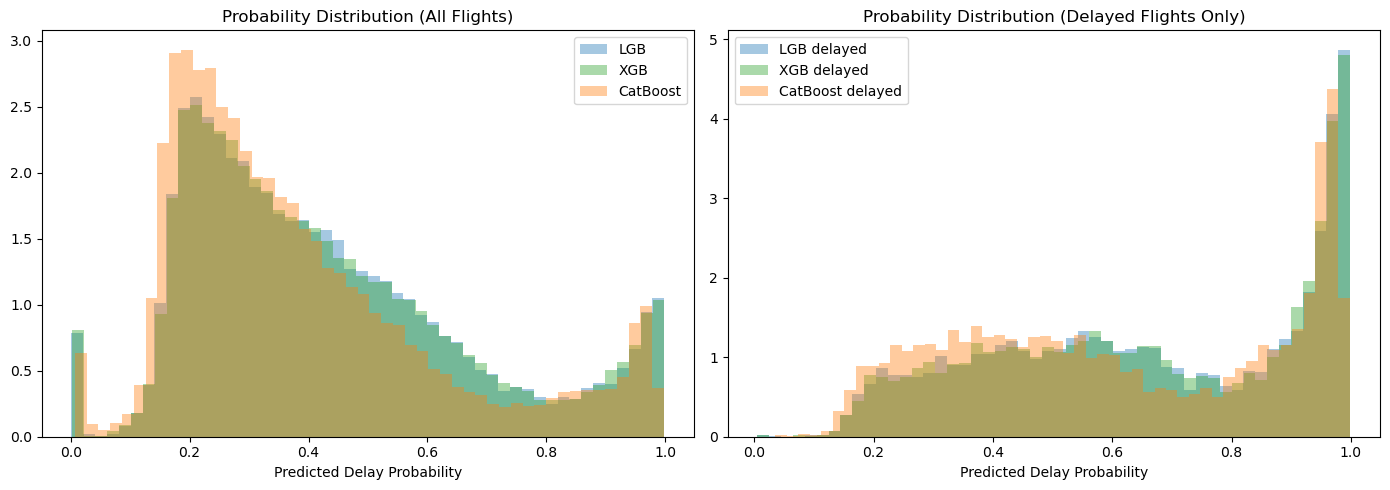

Saved: probability_dist_3model.png


In [19]:
# --- Probability distribution comparison (LGB vs XGB vs CatBoost) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All flights
for name, proba, color in [
    ('LGB', lgb_proba, '#1f77b4'),
    ('XGB', xgb_proba, '#2ca02c'),
    ('CatBoost', cat_bal_proba, '#ff7f0e'),
]:
    axes[0].hist(proba, bins=50, alpha=0.4, label=name, color=color, density=True)
axes[0].set_title('Probability Distribution (All Flights)')
axes[0].set_xlabel('Predicted Delay Probability')
axes[0].legend()

# Delayed flights only
for name, proba, color in [
    ('LGB delayed', lgb_proba[y_test == 1], '#1f77b4'),
    ('XGB delayed', xgb_proba[y_test == 1], '#2ca02c'),
    ('CatBoost delayed', cat_bal_proba[y_test == 1], '#ff7f0e'),
]:
    axes[1].hist(proba, bins=50, alpha=0.4, label=name, color=color, density=True)
axes[1].set_title('Probability Distribution (Delayed Flights Only)')
axes[1].set_xlabel('Predicted Delay Probability')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'probability_dist_3model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: probability_dist_3model.png')


In [20]:
# Calculate metrics for all models at default threshold 0.5

def get_model_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'Accuracy': accuracy_score(y_true, y_pred)
    }

lgb_metrics = get_model_metrics(y_test, lgb_proba, 0.5)
xgb_metrics = get_model_metrics(y_test, xgb_proba, 0.5)
cat_metrics = get_model_metrics(y_test, cat_bal_proba, 0.5)

print("="*70)
print("BASELINE METRICS (Threshold = 0.5)")
print("="*70)
print(f"{'Metric':<15} {'LightGBM':>12} {'XGBoost':>12} {'CatBoost':>12}")
print("-"*55)
for metric in ['AUC-ROC', 'Precision', 'Recall', 'F1 Score', 'Accuracy']:
    print(f"{metric:<15} {lgb_metrics[metric]:>12.4f} {xgb_metrics[metric]:>12.4f} {cat_metrics[metric]:>12.4f}")


BASELINE METRICS (Threshold = 0.5)
Metric              LightGBM      XGBoost     CatBoost
-------------------------------------------------------
AUC-ROC               0.8056       0.8057       0.8038
Precision             0.4478       0.4446       0.5197
Recall                0.6845       0.6843       0.5975
F1 Score              0.5414       0.5390       0.5559
Accuracy              0.7584       0.7561       0.8011


## 10. Threshold Optimization

In [21]:
# Find optimal thresholds for each model (target: recall>=65%, precision>=30%)
from models.threshold_optimizer import find_optimal_threshold

lgb_opt_thresh, lgb_opt_metrics = find_optimal_threshold(
    y_test.values, lgb_proba, target_recall=0.65, min_precision=0.30
)
xgb_opt_thresh, xgb_opt_metrics = find_optimal_threshold(
    y_test.values, xgb_proba, target_recall=0.65, min_precision=0.30
)
cat_opt_thresh, cat_opt_metrics = find_optimal_threshold(
    y_test.values, cat_bal_proba, target_recall=0.65, min_precision=0.30
)

print("="*70)
print("OPTIMIZED METRICS (Target Recall >= 65%, Min Precision >= 30%)")
print("="*70)
print(f"{'Metric':<20} {'LightGBM':>12} {'XGBoost':>12} {'CatBoost':>12}")
print("-"*60)
print(f"{'Optimal Threshold':<20} {lgb_opt_thresh:>12.2f} {xgb_opt_thresh:>12.2f} {cat_opt_thresh:>12.2f}")
print(f"{'Precision':<20} {lgb_opt_metrics['precision']:>12.4f} {xgb_opt_metrics['precision']:>12.4f} {cat_opt_metrics['precision']:>12.4f}")
print(f"{'Recall':<20} {lgb_opt_metrics['recall']:>12.4f} {xgb_opt_metrics['recall']:>12.4f} {cat_opt_metrics['recall']:>12.4f}")
print(f"{'F1 Score':<20} {lgb_opt_metrics['f1']:>12.4f} {xgb_opt_metrics['f1']:>12.4f} {cat_opt_metrics['f1']:>12.4f}")


OPTIMIZED METRICS (Target Recall >= 65%, Min Precision >= 30%)
Metric                   LightGBM      XGBoost     CatBoost
------------------------------------------------------------
Optimal Threshold            0.53         0.53         0.45
Precision                  0.4805       0.4766       0.4631
Recall                     0.6509       0.6529       0.6585
F1 Score                   0.5529       0.5510       0.5438


Figure saved to ../../../outputs/figures/threshold_analysis_lgb.png


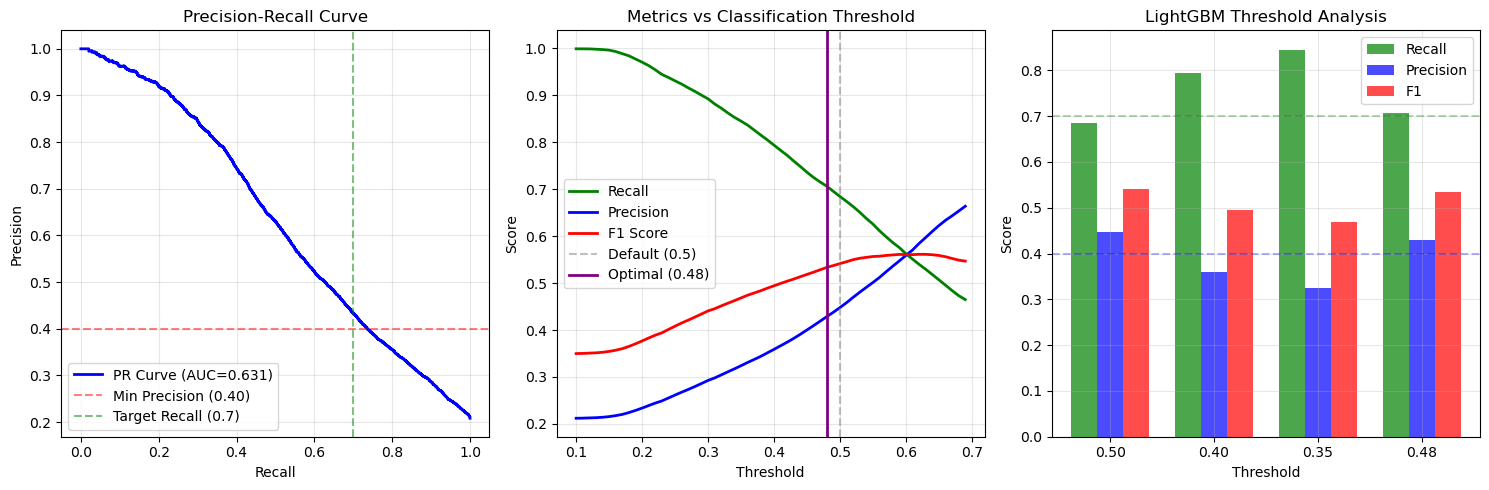

Figure saved to ../../../outputs/figures/threshold_analysis_xgb.png


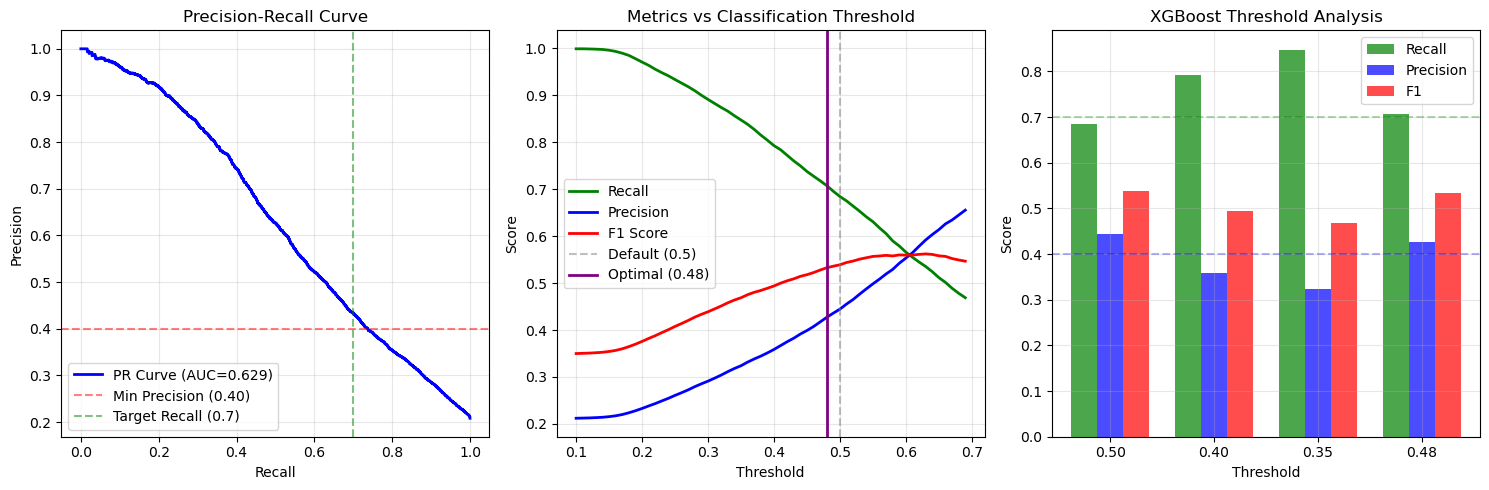

Figure saved to ../../../outputs/figures/threshold_analysis_catboost.png


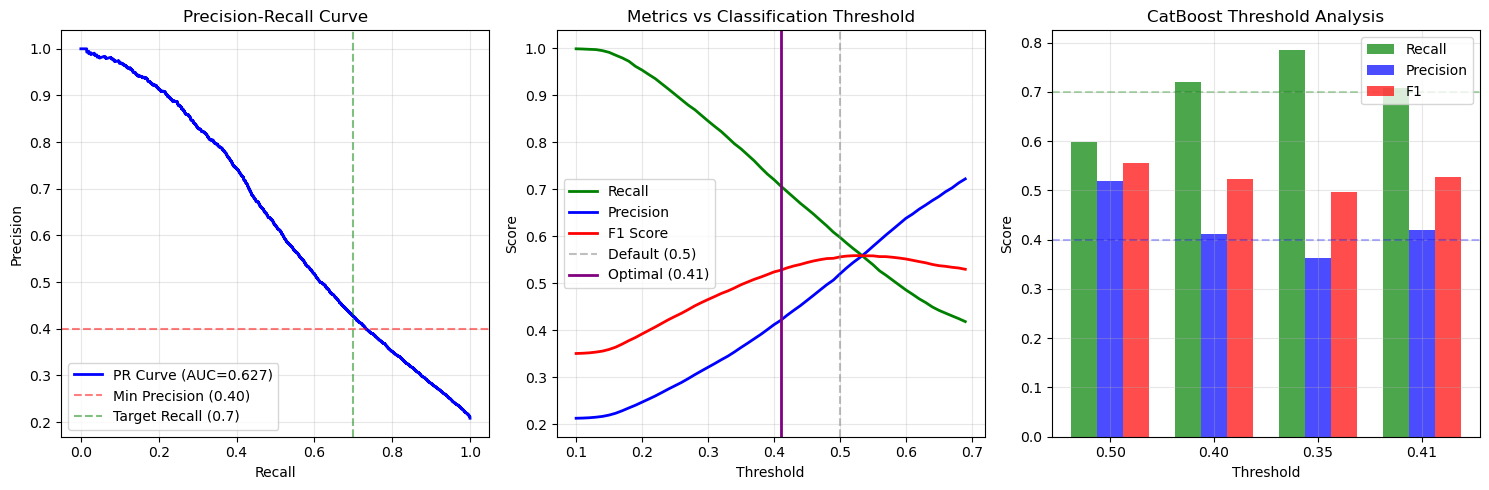

Saved: threshold_analysis_lgb.png, threshold_analysis_xgb.png, threshold_analysis_catboost.png


In [22]:
# Plot threshold analysis for all three models
fig_lgb = plot_threshold_analysis(
    y_test.values, lgb_proba,
    target_recall=0.70,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'threshold_analysis_lgb.png')
)
plt.title('LightGBM Threshold Analysis')
plt.show()

fig_xgb = plot_threshold_analysis(
    y_test.values, xgb_proba,
    target_recall=0.70,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'threshold_analysis_xgb.png')
)
plt.title('XGBoost Threshold Analysis')
plt.show()

fig_cat = plot_threshold_analysis(
    y_test.values, cat_bal_proba,
    target_recall=0.70,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'threshold_analysis_catboost.png')
)
plt.title('CatBoost Threshold Analysis')
plt.show()

print('Saved: threshold_analysis_lgb.png, threshold_analysis_xgb.png, threshold_analysis_catboost.png')


## 11. Full Historical Comparison (V1-V9)

In [23]:
# Full comparison table (including ALL historical versions)
comparison = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Precision (0.5)', 'Recall (0.5)', 'F1 (0.5)',
               'Opt Threshold', 'Precision (Opt)', 'Recall (Opt)', 'F1 (Opt)'],
    'LightGBM': [lgb_metrics['AUC-ROC'], lgb_metrics['Precision'], lgb_metrics['Recall'], lgb_metrics['F1 Score'],
                 lgb_opt_thresh, lgb_opt_metrics['precision'], lgb_opt_metrics['recall'], lgb_opt_metrics['f1']],
    'XGBoost': [xgb_metrics['AUC-ROC'], xgb_metrics['Precision'], xgb_metrics['Recall'], xgb_metrics['F1 Score'],
                xgb_opt_thresh, xgb_opt_metrics['precision'], xgb_opt_metrics['recall'], xgb_opt_metrics['f1']],
    'CatBoost': [cat_metrics['AUC-ROC'], cat_metrics['Precision'], cat_metrics['Recall'], cat_metrics['F1 Score'],
                 cat_opt_thresh, cat_opt_metrics['precision'], cat_opt_metrics['recall'], cat_opt_metrics['f1']],
    'v8 CB (18feat)': [0.8094, 0.476, 0.654, 0.551, 0.48, 0.476, 0.654, 0.551],
    'v7 CB (20feat)': [0.8088, 0.337, 0.738, 0.463, 0.48, 0.476, 0.654, 0.551],
    'v6 (33feat)': [0.7929, 0.338, 0.737, 0.463, 0.35, 0.405, 0.655, 0.501],
    'v5 (38feat)': [0.7931, 0.339, 0.738, 0.465, 0.36, 0.406, 0.667, 0.504],
    'v4 (39feat)': [0.7675, 0.366, 0.650, 0.470, 0.50, 0.366, 0.650, 0.468],
    'v3 (30feat)': [0.7598, 0.361, 0.662, 0.467, 0.50, 0.361, 0.662, 0.467],
    'v2 (35feat)': [0.7587, 0.377, 0.617, 0.468, 0.44, 0.334, 0.617, 0.434],
    'v1 (19feat)': [0.7414, 0.484, 0.462, 0.472, 0.50, 0.484, 0.462, 0.472],
})

print("="*120)
print(f"FULL MODEL COMPARISON (V9.0: 21 features, Jan-Oct 2025 expanded data)")
print("="*120)
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}' if x < 1 else f'{x:.2f}'))


FULL MODEL COMPARISON (V9.0: 21 features, Jan-Oct 2025 expanded data)
         Metric  LightGBM  XGBoost  CatBoost  v8 CB (18feat)  v7 CB (20feat)  v6 (33feat)  v5 (38feat)  v4 (39feat)  v3 (30feat)  v2 (35feat)  v1 (19feat)
        AUC-ROC    0.8056   0.8057    0.8038          0.8094          0.8088       0.7929       0.7931       0.7675       0.7598       0.7587       0.7414
Precision (0.5)    0.4478   0.4446    0.5197          0.4760          0.3370       0.3380       0.3390       0.3660       0.3610       0.3770       0.4840
   Recall (0.5)    0.6845   0.6843    0.5975          0.6540          0.7380       0.7370       0.7380       0.6500       0.6620       0.6170       0.4620
       F1 (0.5)    0.5414   0.5390    0.5559          0.5510          0.4630       0.4630       0.4650       0.4700       0.4670       0.4680       0.4720
  Opt Threshold    0.5300   0.5300    0.4500          0.4800          0.4800       0.3500       0.3600       0.5000       0.5000       0.4400       0.5000


## 12. Risk Tier System

In [24]:
# --- Risk Tier System ---
def assign_risk_tier(probabilities, high_thresh=0.55, med_thresh=0.35):
    """Assign risk tiers based on predicted probability."""
    return np.where(probabilities >= high_thresh, 'HIGH',
           np.where(probabilities >= med_thresh, 'MEDIUM', 'LOW'))

# Evaluate tier system with best model
tiers = assign_risk_tier(cat_bal_proba)

print("="*60)
print(f"RISK TIER ANALYSIS ({"CatBoost (baseline)"})")
print("="*60)
print(f"{'Tier':<10} {'Count':>8} {'% Total':>10} {'Actual Delay %':>16} {'Precision':>12}")
print("-"*58)
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    mask = tiers == tier
    n = mask.sum()
    if n > 0:
        actual = y_test[mask].mean()
        print(f"{tier:<10} {n:>8,} {n/len(y_test)*100:>9.1f}% {actual*100:>15.1f}% {'':>12}")

# Also try different threshold combinations
print(f"\n--- Threshold Sensitivity ---")
for high, med in [(0.60, 0.35), (0.55, 0.35), (0.50, 0.30), (0.55, 0.40)]:
    tiers_test = assign_risk_tier(cat_bal_proba, high, med)
    high_mask = tiers_test == 'HIGH'
    if high_mask.sum() > 0:
        high_precision = y_test[high_mask].mean()
        high_count = high_mask.sum()
        med_mask = tiers_test == 'MEDIUM'
        low_mask = tiers_test == 'LOW'
        low_delay = y_test[low_mask].mean() if low_mask.sum() > 0 else 0
        print(f"  high={high:.2f}, med={med:.2f}: "
              f"HIGH={high_count:,} ({high_precision*100:.0f}% delay), "
              f"LOW delay rate={low_delay*100:.1f}%")

# Store best tier thresholds
tier_high_thresh = 0.55
tier_med_thresh = 0.35
print(f"\nSelected: HIGH >= {tier_high_thresh}, MEDIUM >= {tier_med_thresh}, LOW < {tier_med_thresh}")

RISK TIER ANALYSIS (CatBoost (baseline))
Tier          Count    % Total   Actual Delay %    Precision
----------------------------------------------------------
HIGH          8,541      19.4%            57.8%             
MEDIUM       11,287      25.7%            20.0%             
LOW          24,127      54.9%             8.1%             

--- Threshold Sensitivity ---
  high=0.60, med=0.35: HIGH=6,968 (64% delay), LOW delay rate=8.1%
  high=0.55, med=0.35: HIGH=8,541 (58% delay), LOW delay rate=8.1%
  high=0.50, med=0.30: HIGH=10,530 (52% delay), LOW delay rate=7.1%
  high=0.55, med=0.40: HIGH=8,541 (58% delay), LOW delay rate=9.2%

Selected: HIGH >= 0.55, MEDIUM >= 0.35, LOW < 0.35


## 13. Save Models & Context

In [25]:
# === Save prepared data for downstream notebooks (04, 05, 06) ===
import pickle
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'

arrival_context = {
    'feature_columns': feature_columns,
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'train': train, 'test': test,
    'cutoff': cutoff,
    'train_medians': train_medians if 'train_medians' in dir() else X_train.median(),
}
pickle.dump(arrival_context, open(DATA_PROCESSED / 'arrival_model_context.pkl', 'wb'))
print(f'Saved arrival context: X_train={X_train.shape}, X_test={X_test.shape}')
print(f'Features: {len(feature_columns)}')


Saved arrival context: X_train=(103204, 21), X_test=(43955, 21)
Features: 21


In [26]:
import joblib
lgb_model_path = MODELS_DIR / 'lgb_delay_classifier_v9_0.joblib'
xgb_model_path = MODELS_DIR / 'xgb_delay_classifier_v9_0.joblib'

# Common metadata
common_meta = {
    'feature_columns': feature_columns,
    'split_cutoff': str(cutoff),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'tier_thresholds': {'high': tier_high_thresh, 'medium': tier_med_thresh},
    'gate_target_encoding': gate_target.to_dict(),
    'terminal_target_encoding': terminal_target.to_dict(),
    'airline_target_encoding': airline_target.to_dict(),
    'runway_target_encoding': runway_target.to_dict(),
    'faa_reason_target_encoding': faa_reason_target.to_dict() if faa_reason_target is not None else {},
    'train_delay_rate': float(y_train.mean()),
    'version': 'v9_0',
}

# Save LightGBM
joblib.dump({
    'model': lgb_model,
    'optimal_threshold': lgb_opt_thresh,
    'metrics': lgb_opt_metrics,
    'auc': lgb_metrics['AUC-ROC'],
    'scale_pos_weight': best_lgb_spw,
    **common_meta,
}, lgb_model_path)
print(f"LightGBM saved to: {lgb_model_path}")

# Save XGBoost
joblib.dump({
    'model': xgb_model,
    'optimal_threshold': xgb_opt_thresh,
    'metrics': xgb_opt_metrics,
    'auc': xgb_metrics['AUC-ROC'],
    'scale_pos_weight': best_xgb_spw,
    **common_meta,
}, xgb_model_path)
print(f"XGBoost saved to: {xgb_model_path}")


LightGBM saved to: ../../../models/lgb_delay_classifier_v9_0.joblib
XGBoost saved to: ../../../models/xgb_delay_classifier_v9_0.joblib


In [27]:
# Final summary

print("="*60)
print("MODEL TRAINING COMPLETE (V9.0 — Jan-Oct 2025 expanded data)")

print("="*60)
print(f"Features: {len(feature_columns)} (V9.0: 21 features)")
print(f"  V9.0 changes: -origin_storm_flag, -origin_cloud_cover, -Month")
print(f"                +origin_wx_impact, +lga_wx_impact")
print(f"Data: Jan-Oct 2025 expanded ({len(X_train)+len(X_test):,} arrivals)")
print(f"")
print(f"LightGBM (spw={best_lgb_spw:.1f}):")
print(f"  - AUC-ROC: {lgb_metrics['AUC-ROC']:.4f}")
print(f"  - Threshold: {lgb_opt_thresh:.2f}")
print(f"  - Recall: {lgb_opt_metrics['recall']*100:.1f}%, Precision: {lgb_opt_metrics['precision']*100:.1f}%")
print(f"")
print(f"XGBoost (spw={best_xgb_spw:.1f}):")
print(f"  - AUC-ROC: {xgb_metrics['AUC-ROC']:.4f}")
print(f"  - Threshold: {xgb_opt_thresh:.2f}")
print(f"  - Recall: {xgb_opt_metrics['recall']*100:.1f}%, Precision: {xgb_opt_metrics['precision']*100:.1f}%")
print(f"")
print(f"")
print(f"Risk Tiers: HIGH >= {tier_high_thresh}, MEDIUM >= {tier_med_thresh}")
print(f"Models saved to: {MODELS_DIR}")
print(f"\nNext: Run 04_shap_and_model_analysis.ipynb for SHAP + CB vs LGB analysis")


MODEL TRAINING COMPLETE (V9.0 — Jan-Oct 2025 expanded data)
Features: 21 (V9.0: 21 features)
  V9.0 changes: -origin_storm_flag, -origin_cloud_cover, -Month
                +origin_wx_impact, +lga_wx_impact
Data: Jan-Oct 2025 expanded (147,159 arrivals)

LightGBM (spw=3.5):
  - AUC-ROC: 0.8056
  - Threshold: 0.53
  - Recall: 65.1%, Precision: 48.0%

XGBoost (spw=3.5):
  - AUC-ROC: 0.8057
  - Threshold: 0.53
  - Recall: 65.3%, Precision: 47.7%


Risk Tiers: HIGH >= 0.55, MEDIUM >= 0.35
Models saved to: ../../../models

Next: Run 04_shap_and_model_analysis.ipynb for SHAP + CB vs LGB analysis
